## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [14]:
# Q1 Reading and exploring the data
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

df_og = pd.read_csv('golub.csv')
df = df_og.copy()
df.head()




,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [15]:
# Q1 Relabeling 
df['cancer'] = df['cancer'].replace({'allB': 0, 'allT': 0, 'aml': 1})
df['cancer'].value_counts()


/tmp/ipykernel_51594/1017997125.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cancer'] = df['cancer'].replace({'allB': 0, 'allT': 0, 'aml': 1})


cancer
0    47
1    25
Name: count, dtype: int64

In [16]:
# Q2 Linear Regression

x = df.drop(columns=(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']))
y = df['cancer']


model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

comparison_Df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})

mse = np.mean((y - y_pred) ** 2)

print(comparison_Df.head())

#what is the mean squared error? 6.790229805704473e-30
print(f'The mean squared error is: {mse}')



   Actual     Predicted
0       0  2.553513e-15
1       0 -4.440892e-15
2       0  1.110223e-16
3       0 -2.664535e-15
4       0 -8.881784e-16
The mean squared error is: 6.790229805704473e-30


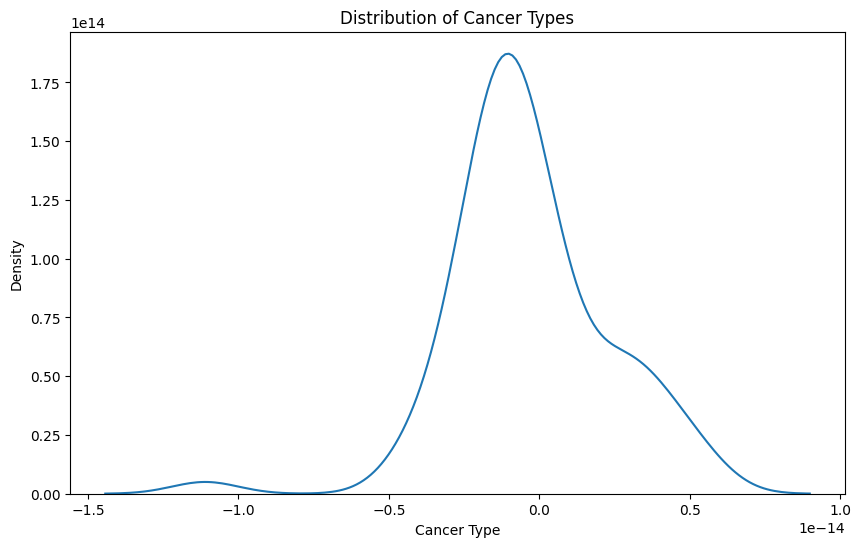

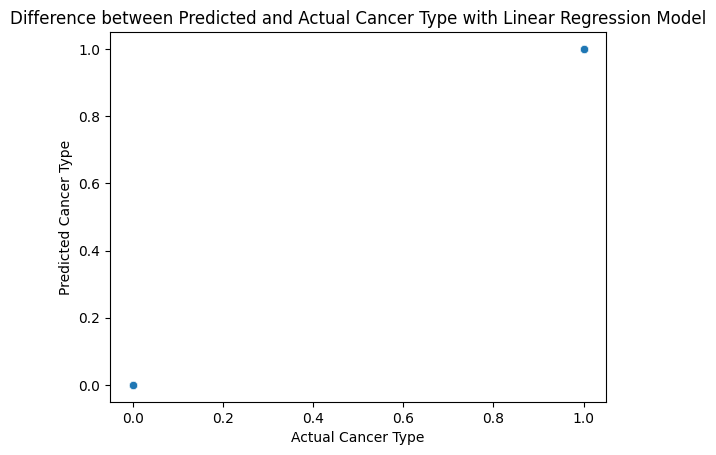

In [17]:
plt.figure(2, figsize=(10, 6))
sns.kdeplot(comparison_Df['Predicted']-comparison_Df['Actual'])
plt.title('Distribution of Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('Density')
plt.show()

sns.scatterplot(data = comparison_Df, x = comparison_Df['Actual'], y = comparison_Df['Predicted'])
plt.title('Difference between Predicted and Actual Cancer Type with Linear Regression Model')
plt.xlabel('Actual Cancer Type')
plt.ylabel('Predicted Cancer Type')
plt.show()

In [18]:
# Q3
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(model, x, y, cv=kfold, scoring='neg_mean_squared_error')
cv_scores_mse = -cv_scores
print(f'5 Fold MSE: {cv_scores_mse}')

cv_scores_mean = cv_scores_mse.mean()
print(f'Mean MSE: {cv_scores_mean}')



5 Fold MSE: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean MSE: 0.043365958986227915


In [20]:
# Q4

from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

#first scale the x matrix of our independent columns. this is important because 
#the values may not have the same units and it makes the results easier to compare
scaler = StandardScaler()
X_sc = scaler.fit_transform(x)


#this alpha_grid is scalling our grid to be logarithmic which allow us to interpret
#data across multiple orders of magnitude
alpha_grid = np.logspace(-4, -2, num=50)

#the lassoCV is a regression that uses cross validation to determine the optimal 
#model that balences the model's complexity and the predictive accuracy by finding
#an alpha that minimizes the cross‑validated MSE. 
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)


alpha_star = lasso_cv.alpha_

#calculating the mean square error for each alpha and finding the index with the lowest error
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)


#now going through each value of alpha (the paramter that weights the influence of a 
#coefficients) to create a list of models' coefficients which we will use with the 
#index of the min
coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)


coefs = np.array(coefs)
coefs
#using index_star here to identitfy the coefficient of the model that has the smallest mse
coefs_star = coefs[index_star]
#np.nonzero to find the position of non-zero data
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = x.columns[selected_idx].tolist()

#the Lasso model of with the most optimal alpha is fitted and then predicted
lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)



print(f'Optimal alpha: {alpha_star:.10f}')
#The total number of selected genes is 70 (found by code below)
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {x.shape[1] - len(selected_genes)}')
#The genes selected are printed by the code below
print(f'The selected genes are: {selected_genes}')

Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059
The selected genes are: ['AF000560_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L13278_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'U37055_rna1_s_at', 'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at', 'U26312

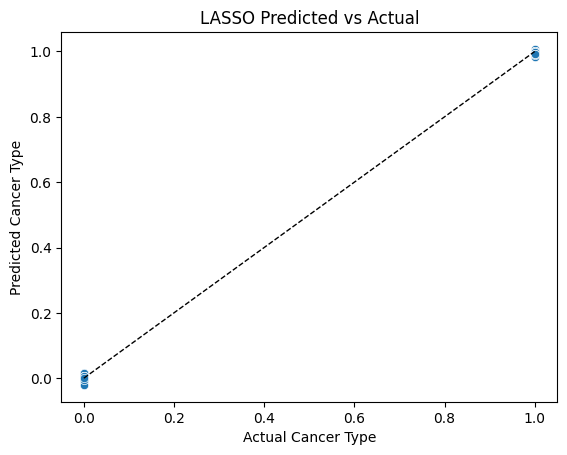

LASSO training MSE: 4.64279e-05


In [21]:
#This scatterplot differs slightly from actual outcome vs the residuals_ols predictions 
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual Cancer Type')
plt.ylabel('Predicted Cancer Type')
plt.show()


mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)
print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')

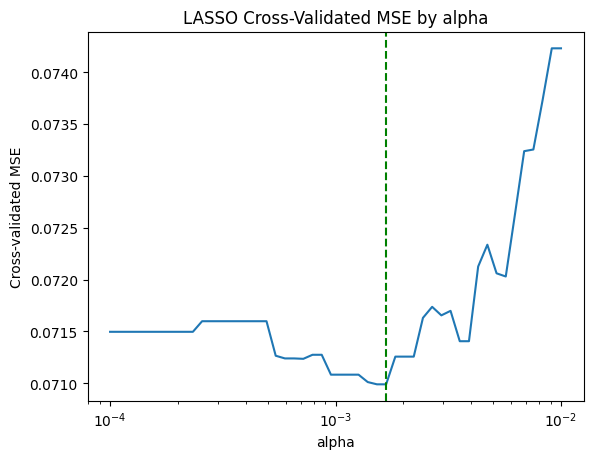

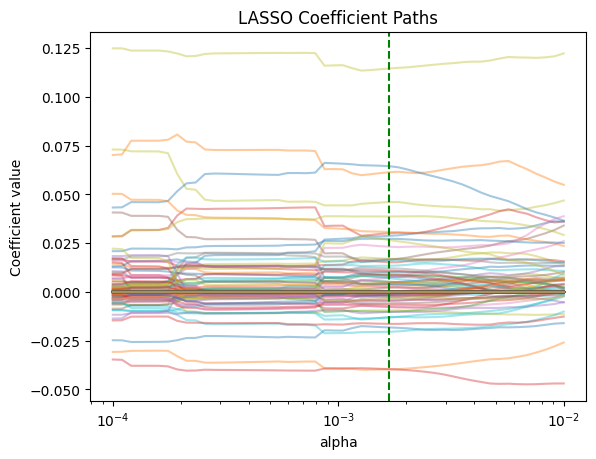

In [22]:
# Q5

sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)

#This line of code below creates a line on the graph that indicates 
#the x value/alpha which is the most optimal
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

#This iterates through the array of coeficients from the models so that we can
#graph each of them and compare as alpha increases. The higher the line produced by 
#the coefficient the more influence that predictor has on the model’s output at that
#value of alpha.

for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

In [ ]:
# Q5 Make a plot that shows the cross validated MSE as $alpha$ 
# varies. For what values of $\alpha$ is the LASSO underfitting?
#  Overfitting? What is the optimal penality hyperparameter that
#  minimizes expected MSE?


# As alpha increases, the coefficient value tends to decrease or 
# on average remain the same. The left side of the line is at risk
# for underfitting because shrinkage means that the model is simplifying
# and coefficents are being reduced/removed. On the right side of the
# line is at risk for overfitting because the alpha is too large and 
# therefore the model is too complex. 

#The optimal penality hyperparamter minimizing the expecte mse is 
#alpha = 0.0016768

alpha_star


np.float64(0.0016768329368110067)

In [ ]:
# Q6

# OLS models fit training data to minimize the squared error in order to 
# make predictions with all the predictors which makes it fit the training
# data perfectly, but means that the predictions will incorporate more noise 
# and unnecessary influence.
# 
# Lasso models specifically minimizing the complexity of the model by removing 
# less influencial predictors. This means that OLS models uses more predictors
# than a Lasso model, which makes the OLS model more suseptable to noise and causing 
# underfitting. The Lasso model also fits the data, however, it shrinks the 
# coefficient so that the model does not account for weaker coefficent's data trends 
# (less noise). This means that the model doesn't fit training data perfectly, however, 
# is more generalized and better for test data predictions. 

In [ ]:
# Q7

# There are so many predictors, however, not all of these predictors and their
# relationships between one another are necesssary for predicting the target 
# variable. With a dataset with so many possible predictors, the complexity of
# a model which incorporate all of these influences will inherently be overfit. 
# Using regularization methods which penalizes complex models helps generalize
# and fit to new data. 


In [ ]:
# Q8

# In general, prediction are based on previous data and trends. Correlation does not equal
#causastion, so using prediction based on the correlation between features will never be 100% 
# accurate. In the context of health care, relying solely on predictions that are based on 
# past trends will result in some inaccuracies and these inaccuracies can be potentially fatal 
# to patient's. 